In [1]:
import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('../../data/processed/WineDataset_clean.csv')
print(f"Shape: {df.shape}")

Shape: (1286, 12)


In [3]:
# --- Feature Engineering din Description ---

# 1. Are premii? (award, medal, trophy)
df['has_award'] = df['Description'].str.contains(
    r'award|medal|trophy', case=False, regex=True).astype(int)

# 2. Scor de la critici (ex: "92 points", "94 points")
df['critic_score'] = df['Description'].str.extract(r'(\d{2})\s*points').astype(float)
df['has_critic_score'] = df['critic_score'].notna().astype(int)
df['critic_score'] = df['critic_score'].fillna(0)

# 3. Organic / biodynamic
df['is_organic'] = df['Description'].str.contains(
    r'organic|biodynamic', case=False, regex=True).astype(int)

# 4. Oak aging (ex: "aged 12 months in oak")
df['oak_aged'] = df['Description'].str.contains(
    r'oak', case=False, regex=True).astype(int)

# 5. Hand-picked / hand-harvested
df['handpicked'] = df['Description'].str.contains(
    r'hand-?pick|hand-?harvest', case=False, regex=True).astype(int)

# 6. Prestigiu / istorie (ex: "founded in 1730", "since 1824")
df['has_history'] = df['Description'].str.contains(
    r'centur|founded|history|heritage|est(?:ablished)?\.?\s*\d{4}', case=False, regex=True).astype(int)

# 7. Menționează Grand Cru / clasificari premium
df['premium_classification'] = df['Description'].str.contains(
    r'grand cru|premier cru|gran reserva|cru class|classified', case=False, regex=True).astype(int)

# 8. Royal / celebrity endorsement
df['prestige_endorsement'] = df['Description'].str.contains(
    r'royal|queen|king|tsar|celebrity|state banquet', case=False, regex=True).astype(int)

# 9. Lungimea descrierii (proxy pentru efort de marketing)
df['desc_length'] = df['Description'].str.split().str.len()

# Cate vinuri au fiecare feature?
new_features = ['has_award', 'has_critic_score', 'is_organic', 'oak_aged', 
                'handpicked', 'has_history', 'premium_classification', 
                'prestige_endorsement']
for f in new_features:
    print(f"{f}: {df[f].sum()} vinuri ({df[f].mean()*100:.1f}%)")

has_award: 228 vinuri (17.7%)
has_critic_score: 41 vinuri (3.2%)
is_organic: 73 vinuri (5.7%)
oak_aged: 286 vinuri (22.2%)
handpicked: 53 vinuri (4.1%)
has_history: 208 vinuri (16.2%)
premium_classification: 68 vinuri (5.3%)
prestige_endorsement: 386 vinuri (30.0%)


In [4]:
# Corelatia cu pretul
correlations = df[new_features + ['critic_score', 'desc_length', 'Price_clean']].corr()['Price_clean'].sort_values(ascending=False)
print(correlations)

# Pretul mediu cu/fara fiecare feature
for f in new_features:
    avg_with = df[df[f]==1]['Price_clean'].mean()
    avg_without = df[df[f]==0]['Price_clean'].mean()
    print(f"{f}: cu={avg_with:.2f}£ | fara={avg_without:.2f}£")

Price_clean               1.000000
premium_classification    0.167508
critic_score              0.075814
has_critic_score          0.067549
handpicked                0.038444
has_history               0.022479
is_organic               -0.005060
oak_aged                 -0.008375
prestige_endorsement     -0.014632
desc_length              -0.075774
has_award                -0.081380
Name: Price_clean, dtype: float64
has_award: cu=22.26£ | fara=29.82£
has_critic_score: cu=41.70£ | fara=28.05£
is_organic: cu=27.75£ | fara=28.53£
oak_aged: cu=27.93£ | fara=28.64£
handpicked: cu=35.07£ | fara=28.20£
has_history: cu=30.30£ | fara=28.13£
premium_classification: cu=53.65£ | fara=27.08£
prestige_endorsement: cu=27.69£ | fara=28.82£


In [5]:
# Features
cat_cols = ['Capacity', 'Grape', 'Closure', 'Country', 'Type', 'Region', 'Style', 'Vintage']
num_cols = ['ABV']
eng_features = ['has_award', 'has_critic_score', 'critic_score', 'is_organic', 
                'oak_aged', 'handpicked', 'has_history', 'premium_classification', 
                'prestige_endorsement', 'desc_length']
target = 'Price_log'

y = df[target]
X_train_idx, X_test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
y_train, y_test = y.loc[X_train_idx], y.loc[X_test_idx]

# Tabular preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ('num', 'passthrough', num_cols)
])
X_train_tab = preprocessor.fit_transform(df.loc[X_train_idx, cat_cols + num_cols])
X_test_tab = preprocessor.transform(df.loc[X_test_idx, cat_cols + num_cols])

# Engineered features
X_train_eng = df.loc[X_train_idx, eng_features].values
X_test_eng = df.loc[X_test_idx, eng_features].values

def evaluate(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    print(f"=== {name} ===")
    print(f"R²: {r2:.4f} | RMSE (£): {rmse:.2f}")
    return r2, rmse

results = {}

# 1. Tabular only (referinta)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tab, y_train)
r2, rmse = evaluate("Tabular only", y_test, rf.predict(X_test_tab))
results['Tabular only'] = (r2, rmse)

# 2. Tabular + Engineered features
X_train_c = sp.hstack([X_train_tab, sp.csr_matrix(X_train_eng)])
X_test_c = sp.hstack([X_test_tab, sp.csr_matrix(X_test_eng)])
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_c, y_train)
r2, rmse = evaluate("Tabular + Engineered", y_test, rf2.predict(X_test_c))
results['Tabular + Engineered'] = (r2, rmse)

# 3. Engineered only
rf3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(X_train_eng, y_train)
r2, rmse = evaluate("Engineered only", y_test, rf3.predict(X_test_eng))
results['Engineered only'] = (r2, rmse)

=== Tabular only ===
R²: 0.6037 | RMSE (£): 26.66
=== Tabular + Engineered ===
R²: 0.6181 | RMSE (£): 26.96
=== Engineered only ===
R²: 0.0373 | RMSE (£): 32.24


In [6]:
# Feature importance
feature_names = list(preprocessor.get_feature_names_out()) + eng_features
importances = pd.Series(rf2.feature_importances_, index=feature_names)
print(importances.sort_values(ascending=False).head(20))

cat__Style_Rich & Toasty            0.147565
desc_length                         0.088369
cat__Closure_Screwcap               0.071938
cat__Region_Unknown                 0.066723
num__ABV                            0.062956
cat__Country_France                 0.059055
cat__Closure_Natural Cork           0.023646
cat__Style_Savoury & Full Bodied    0.016354
cat__Vintage_2022                   0.016311
cat__Region_Burgundy                0.015811
cat__Grape_Pinot Noir               0.013418
cat__Vintage_2021                   0.012659
cat__Country_Spain                  0.012090
cat__Grape_Chardonnay               0.010955
critic_score                        0.010181
cat__Capacity_75CL                  0.009743
cat__Vintage_2015                   0.009737
prestige_endorsement                0.009369
cat__Vintage_2008                   0.008574
oak_aged                            0.008322
dtype: float64


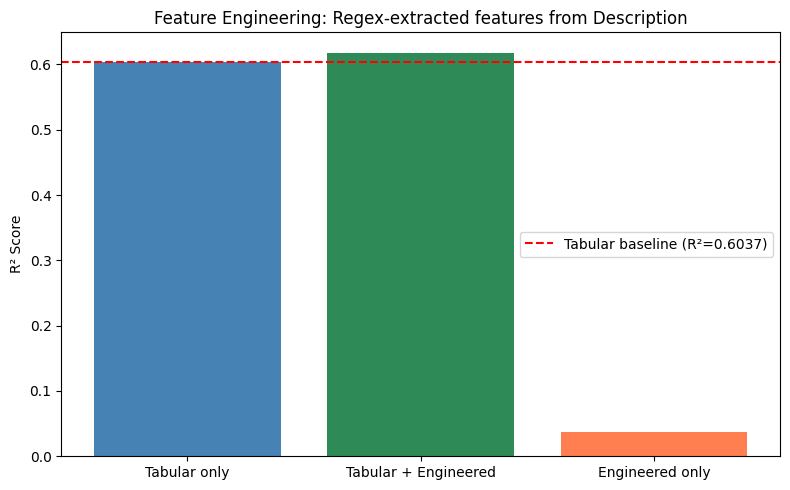

In [7]:
# Comparison chart
models = list(results.keys())
r2_scores = [results[m][0] for m in models]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, r2_scores, color=['steelblue', 'seagreen', 'coral'])
plt.axhline(y=0.6037, color='red', linestyle='--', label='Tabular baseline (R²=0.6037)')
plt.ylabel('R² Score')
plt.title('Feature Engineering: Regex-extracted features from Description')
plt.legend()
plt.tight_layout()
plt.show()

# Wine Dataset - Feature Engineering: Regex-based extraction from Description

## Goal
Instead of using an LLM to generate features from Description (Option 1 from supervisor),
we extract structured features deterministically using regex patterns.

## Extracted Features
- `has_award` — mentions award/medal/trophy (17.7%)
- `critic_score` — numeric score like "92 points" (3.2%)
- `is_organic` — organic/biodynamic (5.7%)
- `oak_aged` — oak aging mentioned (22.2%)
- `handpicked` — hand-picked grapes (4.1%)
- `has_history` — heritage/founded/century (16.2%)
- `premium_classification` — Grand Cru/Reserva etc. (5.3%)
- `prestige_endorsement` — royal/celebrity mentions (30.0%)
- `desc_length` — word count of description

## Results

| Model | R² | RMSE (£) |
|-------|-----|---------|
| Tabular only | 0.6037 | £26.66 |
| **Tabular + Engineered** | **0.6181**  | £26.96 |
| Engineered only | 0.04 | £32.24 |

## Key Findings
- **First method to beat the tabular baseline!** (R² 0.6037 → 0.6181)
- 10 interpretable features achieved what 4096-dim embeddings could not
- `desc_length` is surprisingly predictive (2nd most important feature overall)
- Counterintuitive: `has_award` correlates NEGATIVELY with price — awards are 
  marketing for affordable wines, premium wines don't need them
- `premium_classification` wines cost 2x more on average (£53.65 vs £27.08)

## Comparison vs LLM approach (Option 1)
- Deterministic: same input → same output (no hallucination)
- Fast: ~1 second vs hours of LLM inference
- Interpretable: each feature has clear meaning
- Limitation: misses unusual phrasings an LLM would understand